# Assignment 3: Gamma, SQL Left Join, and Implied Volatility

This notebook preserves the completed solution logic and reorganizes it for
exam revision. Each question contains an English problem summary, an
independently runnable solution, Chinese line-level hints, and result guidance.

## Questions

1. Gamma from Delta
2. SQL LEFT JOIN
3. Put implied volatility across strikes

## Recommended Answer Structure

1. State the financial or statistical objective.
2. Identify inputs, assumptions, and units.
3. Write the main formula or algorithm before coding.
4. Complete the code in execution order.
5. Report and interpret the result.
6. Add a short validation or reasonableness check.

## Assignment Review Checklist

- Each question can run independently.
- Imports are included in the question's own code cell.
- Random simulations use a fixed seed.
- The final answer includes interpretation, not only printed output.
- Any chart is discussed in the result Markdown.


## Question 1: Gamma from Delta

Compare the Black-Scholes closed-form gamma with a central finite-difference approximation.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [1]:
'''
本题计算 Delta、解析 Gamma 和数值 Gamma。
中心差分公式 C(S+h)-2C(S)+C(S-h) 除以 h²。
'''
from math import exp, log, pi, sqrt
from scipy import stats

def black_scholes_call(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + sigma**2 / 2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * stats.norm.cdf(d1) - K * exp(-r * T) * stats.norm.cdf(d2)

def delta_closed_form(S, K, T, r, sigma):
    # 看涨期权 Delta = N(d1)
    d1 = (log(S / K) + (r + sigma**2 / 2) * T) / (sigma * sqrt(T))
    return stats.norm.cdf(d1)

def gamma_closed_form(S, K, T, r, sigma):
    # Gamma = 标准正态密度 n(d1) / (S*sigma*sqrt(T))
    d1 = (log(S / K) + (r + sigma**2 / 2) * T) / (sigma * sqrt(T))
    return stats.norm.pdf(d1) / (S * sigma * sqrt(T))

def gamma_numerical(S, K, T, r, sigma, bump=1e-3):
    c_down = black_scholes_call(S - bump, K, T, r, sigma)
    c_mid = black_scholes_call(S, K, T, r, sigma)
    c_up = black_scholes_call(S + bump, K, T, r, sigma)
    # 二阶中心差分近似期权价格对 S 的二阶导数
    return (c_up - 2 * c_mid + c_down) / bump**2

S, K, T, r, sigma = 40, 40, 0.5, 0.01, 0.2
print("Delta =", round(float(delta_closed_form(S, K, T, r, sigma)), 6))
print("Closed-form Gamma =", round(float(gamma_closed_form(S, K, T, r, sigma)), 6))
print("Numerical Gamma =", round(float(gamma_numerical(S, K, T, r, sigma)), 6))


Delta = 0.542235
Closed-form Gamma = 0.070128
Numerical Gamma = 0.070128


**Result interpretation.** The numerical and analytical gamma values should be very close when the bump is small but not dominated by floating-point error.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

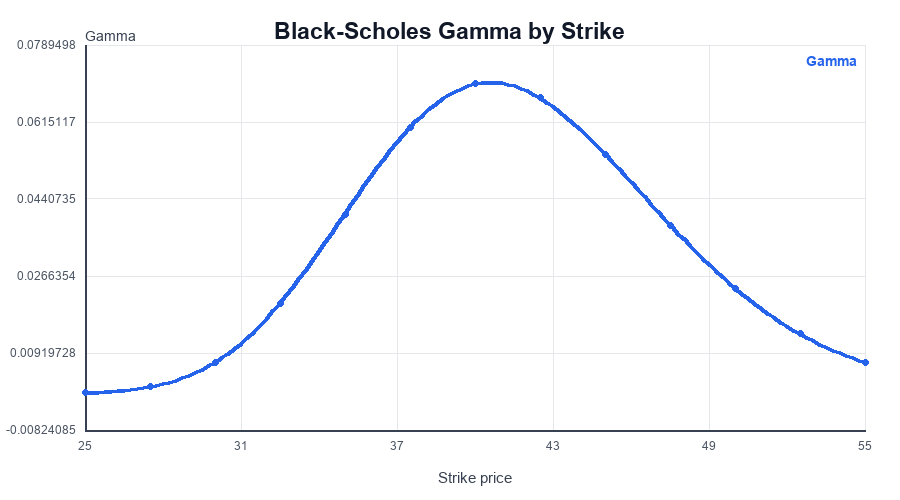


## Question 2: SQL LEFT JOIN

Retain every employee from the left table, including an employee without a matching department.


### Structured Review

- **Left table:** Decide which records must always remain in the result.
- **Join key:** Confirm that both tables use compatible identifiers.
- **Join type:** Use inner for matched records, left/right for preserving one table, and outer for the union.
- **Missing match:** Expect null values when a preserved record has no counterpart.

### Exam Focus

- Complete the `ON left.key = right.key` condition.
- Predict which rows survive each join type.
- Close the database connection after reading results.

### Common Mistakes

- Joining on the wrong column.
- Expecting a left join to discard unmatched left-side rows.
- Confusing SQL `NULL` with the text string `"None"`.


In [2]:
'''
本题在内存数据库中创建两张表，并执行 LEFT JOIN。
LEFT JOIN 保留左表全部记录，未匹配字段返回 NULL。
'''
import sqlite3

connection = sqlite3.connect(":memory:")
cursor = connection.cursor()

cursor.execute("CREATE TABLE departments (dept_id INTEGER PRIMARY KEY, dept_name TEXT)")
cursor.execute("CREATE TABLE employees (id INTEGER PRIMARY KEY, name TEXT, dept_id INTEGER)")
cursor.executemany("INSERT INTO departments VALUES (?, ?)", [(10, "Engineering"), (20, "Sales"), (30, "Marketing")])
cursor.executemany("INSERT INTO employees VALUES (?, ?, ?)", [(1, "Alice", 10), (2, "Bob", 20), (3, "Charlie", None)])

query = '''
SELECT employees.name, departments.dept_name
FROM employees
LEFT JOIN departments
    ON employees.dept_id = departments.dept_id
ORDER BY employees.id
'''

# execute 后 fetchall 读取查询结果
cursor.execute(query)
rows = cursor.fetchall()
connection.close()

print("name | department")
for name, department in rows:
    print(name, "|", department)


name | department
Alice | Engineering
Bob | Sales
Charlie | None


**Result interpretation.** Charlie remains in the result with a null department, demonstrating the key difference from an inner join.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## Question 3: Put Implied Volatility

Use a grid search to find the volatility that makes the Black-Scholes put price closest to each market midpoint.


### Structured Review

- **Market inputs:** Identify spot price, strike, maturity, risk-free rate, volatility, and option premium.
- **Intermediate variables:** Compute `d1` before `d2`; both depend on consistent annualized inputs.
- **Distribution functions:** Distinguish the normal PDF from the normal CDF.
- **Sensitivity:** Interpret the result as a price or derivative with respect to an input.

### Exam Focus

- Reproduce the `d1` and `d2` sequence.
- Select `cdf` for option probabilities and `pdf` for Gamma.
- Check whether the formula is for a call, put, Delta, or Gamma.

### Common Mistakes

- Reversing spot and strike in the logarithm.
- Omitting the square root of maturity.
- Using percentage volatility such as `20` instead of decimal volatility `0.20`.


In [3]:
'''
本题对多个行权价逐一反求 put 隐含波动率。
核心是最小化模型价格与市场中间价的绝对误差。
'''
from math import exp, log, sqrt
from scipy import stats

def black_scholes_put(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + sigma**2 / 2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    # put = K*e^(-rT)*N(-d2) - S*N(-d1)
    return K * exp(-r * T) * stats.norm.cdf(-d2) - S * stats.norm.cdf(-d1)

def implied_volatility_put(S, K, T, r, market_price):
    best_sigma = None
    minimum_error = float("inf")

    for step in range(1, 5001):
        # 搜索区间为 0.01% 至 50%
        sigma = 0.0001 * step
        model_price = black_scholes_put(S, K, T, r, sigma)
        error = abs(model_price - market_price)

        # 只有误差更小时才更新当前最优波动率
        if error < minimum_error:
            minimum_error = error
            best_sigma = sigma
    return best_sigma, minimum_error

option_rows = [
    {"Bid": 1.05, "Ask": 1.15, "Strike": 36},
    {"Bid": 2.10, "Ask": 2.30, "Strike": 40},
    {"Bid": 4.75, "Ask": 5.05, "Strike": 44},
]

S, T, r = 40, 0.5, 0.01
for row in option_rows:
    # 市场中间价 = (Bid+Ask)/2
    midpoint = (row["Bid"] + row["Ask"]) / 2
    implied_vol, error = implied_volatility_put(S, row["Strike"], T, r, midpoint)
    print(
        f"K={row['Strike']}, midpoint={midpoint:.2f}, "
        f"implied vol={implied_vol:.2%}, error={error:.6f}"
    )


K=36, midpoint=1.10, implied vol=25.20%, error=0.000036
K=40, midpoint=2.20, implied vol=20.44%, error=0.000277
K=44, midpoint=4.90, implied vol=21.88%, error=0.000017


**Result interpretation.** The strike-by-strike estimates form the raw data for a volatility smile.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

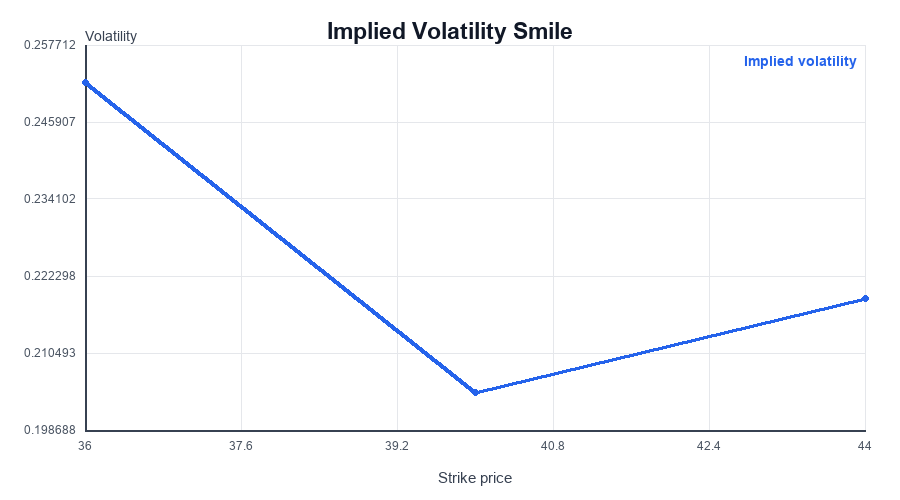
